## imports

In [1]:
import numpy as np
import pandas as pd
import hypertools as hyp
import numpy as np
import os
import re
import pickle
from num2words import num2words
from scipy.spatial.distance import cdist
from scipy.signal import resample
from scipy.stats import zscore
from scipy.spatial.distance import correlation
from scipy.interpolate import interp1d as interpolate
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d
import seaborn as sns
%matplotlib inline

## set paths

In [166]:
ep_model_dir = '../../data/models/episodes/'
ep_traj_dir = os.path.join(ep_model_dir, 't100_w50/', 'trajectories')
ep_seg_dir = os.path.join(ep_model_dir, 't100_w50/', 'events')
ep_emb_dir = os.path.join(ep_model_dir, 't100_w50/', 'embeddings')
rec_model_dir = '../../data/models/participants/'
rec_traj_dir = os.path.join(rec_model_dir, 'trajectories')
rec_seg_dir = os.path.join(rec_model_dir, 'events', 'k:50')
rec_emb_dir = os.path.join(rec_model_dir, 'embeddings')
pickle_dir = '../../data/pickles/'

## load data

In [3]:
# episode trajectories
episode_trajectories = {episode : np.load(os.path.join(ep_traj_dir,episode+'_model_t100_w50_res.npy')) for episode
                       in ['atlep1','atlep2','arrdev']}

# episode events
# episode_events = {episode : np.load(os.path.join(ep_seg_dir,episode+'_events.npy')) 
#                   for episode in ['atlep1','atlep2','arrdev']}

# individual participant trajectories
participant_trajectories = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_traj_dir):
    traj_models = [f for f in files if f.startswith('debug') and f.endswith('.npy')]
    for f_name in traj_models:
        t = np.load(os.path.join(root,f_name))
        participant_trajectories[os.path.split(root)[-1]].append((f_name.split('.')[0],t))
        
# average participant trajectories
avg_participant_trajectories = {rectype : np.load(os.path.join(rec_traj_dir, rectype, 'avg_trajectory.npy')) for 
                               rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}


# individual participant events
# participant_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

# for root, dirs, files in os.walk(rec_seg_dir):
#     events_models = [f for f in files if f.startswith('debug') and f.endswith('events.npy')]
#     for f_name in events_models:
#         m = np.load(os.path.join(root,f_name))
#         participant_events[os.path.split(root)[-1]].append((f_name.split('_')[0],m))

# average participant events
# avg_participant_events = {rectype : np.load(os.path.join(rec_seg_dir,rectype,'avg_events.npy')) 
#                          for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}
        
# episode-recall event mappings
# event_mappings = dict()
# for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']:
#     with open(os.path.join(rec_seg_dir,rectype,'event_mappings.p'), 'rb') as f:
#         event_mappings[rectype] = pickle.load(f)

## compare variability among participants for immediate and delayed recall

In [104]:
imm_trajs = [traj for turkid, traj in participant_trajectories['atlep1']]
sub_dists_i = []

for traj in imm_trajs:
    sub_dists_i.append(np.diag(cdist(avg_participant_trajectories['atlep1'], traj, metric='euclidean')))

immediate_variance = np.mean(sub_dists_i, axis=0)

In [120]:
del_trajs = [traj for turkid, traj in participant_trajectories['delayed']]
sub_dists_d = []

for traj in del_trajs:
    sub_dists_d.append(np.diag(cdist(avg_participant_trajectories['delayed'], traj, metric='euclidean')))

delayed_variance = np.mean(sub_dists_d, axis=0)

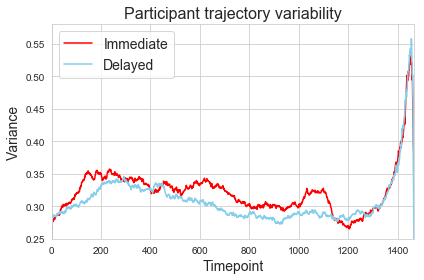

In [147]:
plt.plot(immediate_variance, color='red', label='Immediate')
plt.plot(delayed_variance, color='skyblue', label='Delayed')
plt.xlim((0,1466))
plt.ylim((0.25,0.58))
plt.title('Participant trajectory variability', fontsize=16)
plt.xlabel('Timepoint', fontsize=14)
plt.ylabel('Variance', fontsize=14)
plt.legend(loc=2, fontsize=14)

plt.tight_layout()
#plt.savefig('../../figures/immediate-delayed-variance.pdf')

## compare episode-recall distance for each timepoint between immediate and delayed recall

In [163]:
immediate_distance = np.diag(cdist(avg_participant_trajectories['atlep1'], episode_trajectories['atlep1'], 
                                   metric='euclidean'))
delayed_distance = np.diag(cdist(avg_participant_trajectories['delayed'], episode_trajectories['atlep1'], 
                                   metric='euclidean'))

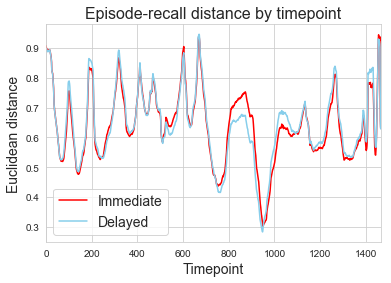

In [164]:
plt.plot(immediate_distance, color='red', label='Immediate')
plt.plot(delayed_distance, color='skyblue', label='Delayed')
plt.xlim((0,1466))
#plt.ylim((0.25,0.58))
plt.title('Episode-recall distance by timepoint', fontsize=16)
plt.xlabel('Timepoint', fontsize=14)
plt.ylabel('Euclidean distance', fontsize=14)
plt.legend(fontsize=14)
#plt.savefig('../../figures/immediate-delayed-ep-rec-euc-dist.pdf')

In [157]:
immediate_distance = np.diag(1-cdist(avg_participant_trajectories['atlep1'], episode_trajectories['atlep1'], 
                                   metric='correlation'))
delayed_distance = np.diag(1-cdist(avg_participant_trajectories['delayed'], episode_trajectories['atlep1'], 
                                   metric='correlation'))

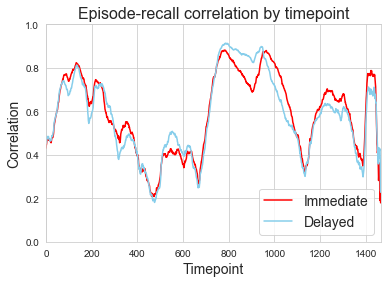

In [161]:
plt.plot(immediate_distance, color='red', label='Immediate')
plt.plot(delayed_distance, color='skyblue', label='Delayed')
plt.xlim((0,1466))
plt.ylim((0,1))
plt.title('Episode-recall correlation by timepoint', fontsize=16)
plt.xlabel('Timepoint', fontsize=14)
plt.ylabel('Correlation', fontsize=14)
plt.legend(fontsize=14)
#plt.savefig('../../figures/immediate-delayed-ep-rec-corr.pdf')

## try with sherlock-proportional episode windows

In [169]:
ep_prop_traj_dir = os.path.join(ep_model_dir, 't100_wProp', 'trajectories')
rec_prop_traj_dir = os.path.join(rec_traj_dir, 'vidwProp')

# episode trajectories
episode_trajectories_prop = {episode : np.load(os.path.join(ep_prop_traj_dir, episode+'_model_t100_wProp_res.npy')) 
                        for episode in ['atlep1','atlep2','arrdev']}

# individual participant trajectories
participant_trajectories_prop = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_prop_traj_dir):
    traj_models = [f for f in files if f.startswith('debug') and f.endswith('.npy')]
    for f_name in traj_models:
        t = np.load(os.path.join(root,f_name))
        participant_trajectories_prop[os.path.split(root)[-1]].append((f_name.split('.')[0],t))
        
# average participant trajectories
avg_participant_trajectories_prop = {rectype : np.load(os.path.join(rec_prop_traj_dir, rectype, 
                                                                    'avg_trajectory.npy')) 
                                     for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}

In [170]:
imm_trajs = [traj for turkid, traj in participant_trajectories_prop['atlep1']]
sub_dists_i = []

for traj in imm_trajs:
    sub_dists_i.append(np.diag(cdist(avg_participant_trajectories_prop['atlep1'], traj, metric='euclidean')))

immediate_variance = np.mean(sub_dists_i, axis=0)

In [171]:
del_trajs = [traj for turkid, traj in participant_trajectories_prop['delayed']]
sub_dists_d = []

for traj in del_trajs:
    sub_dists_d.append(np.diag(cdist(avg_participant_trajectories_prop['delayed'], traj, metric='euclidean')))

delayed_variance = np.mean(sub_dists_d, axis=0)

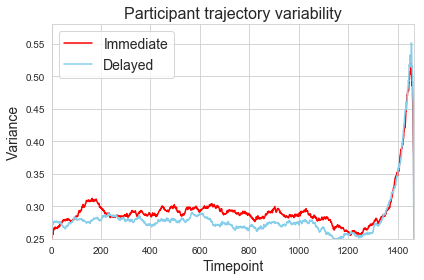

In [172]:
plt.plot(immediate_variance, color='red', label='Immediate')
plt.plot(delayed_variance, color='skyblue', label='Delayed')
plt.xlim((0,1466))
plt.ylim((0.25,0.58))
plt.title('Participant trajectory variability', fontsize=16)
plt.xlabel('Timepoint', fontsize=14)
plt.ylabel('Variance', fontsize=14)
plt.legend(loc=2, fontsize=14)

plt.tight_layout()
#plt.savefig('../../figures/immediate-delayed-variance.pdf')

In [173]:
immediate_distance = np.diag(cdist(avg_participant_trajectories_prop['atlep1'], episode_trajectories_prop['atlep1'], 
                                   metric='euclidean'))
delayed_distance = np.diag(cdist(avg_participant_trajectories_prop['delayed'], episode_trajectories_prop['atlep1'], 
                                   metric='euclidean'))

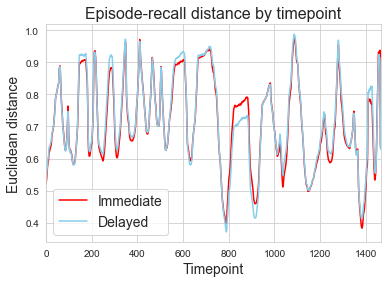

In [174]:
plt.plot(immediate_distance, color='red', label='Immediate')
plt.plot(delayed_distance, color='skyblue', label='Delayed')
plt.xlim((0,1466))
#plt.ylim((0.25,0.58))
plt.title('Episode-recall distance by timepoint', fontsize=16)
plt.xlabel('Timepoint', fontsize=14)
plt.ylabel('Euclidean distance', fontsize=14)
plt.legend(fontsize=14)
#plt.savefig('../../figures/immediate-delayed-ep-rec-euc-dist.pdf')

In [175]:
immediate_distance = np.diag(1-cdist(avg_participant_trajectories_prop['atlep1'], episode_trajectories_prop['atlep1'], 
                                   metric='correlation'))
delayed_distance = np.diag(1-cdist(avg_participant_trajectories_prop['delayed'], episode_trajectories_prop['atlep1'], 
                                   metric='correlation'))

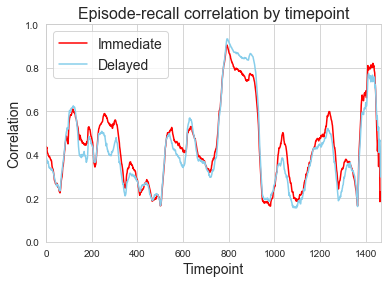

In [176]:
plt.plot(immediate_distance, color='red', label='Immediate')
plt.plot(delayed_distance, color='skyblue', label='Delayed')
plt.xlim((0,1466))
plt.ylim((0,1))
plt.title('Episode-recall correlation by timepoint', fontsize=16)
plt.xlabel('Timepoint', fontsize=14)
plt.ylabel('Correlation', fontsize=14)
plt.legend(fontsize=14)
#plt.savefig('../../figures/immediate-delayed-ep-rec-corr.pdf')

In [177]:
len([i for i in np.var(episode_trajectories_prop['atlep1'], axis=0) if i > 0.001])

22

In [178]:
len([i for i in np.var(episode_trajectories_prop['atlep2'], axis=0) if i > 0.001])

29

In [179]:
len([i for i in np.var(episode_trajectories_prop['arrdev'], axis=0) if i > 0.001])

30

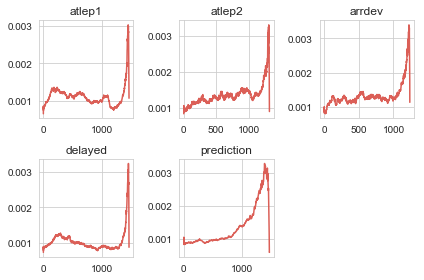

In [78]:

for i, rectype in enumerate(participant_trajectories.keys()):
    test = [traj for turkid, traj in participant_trajectories[rectype]]
    plt.subplot(2,3,i+1)
    plt.plot(np.mean(np.var(test, axis=0), axis=1))
    plt.title(rectype)
    
plt.tight_layout()
plt.savefig('/Users/paxtonfitzpatrick/Desktop/variances')

In [57]:
np.mean(np.var(test, axis=0), axis=1)

array([0.0008317 , 0.0010113 , 0.00086046, ..., 0.00201697, 0.00180354,
       0.00113916])

In [80]:
from scipy.spatial.distance import pdist

In [99]:
np.diag(cdist(avg_participant_trajectories['atlep1'], participant_trajectories['atlep1'][0][1]))

array([0.30014879, 0.29606323, 0.28606609, ..., 0.41288721, 0.36220569,
       0.10708674])

In [93]:
participant_trajectories['atlep1'][0][1]

array([[1.66666667e-04, 1.66666667e-04, 1.66666667e-04, ...,
        1.66666667e-04, 1.66666667e-04, 1.66666667e-04],
       [1.06424122e-05, 1.06424122e-05, 1.06424122e-05, ...,
        1.06424122e-05, 1.06424122e-05, 4.32966773e-06],
       [3.75758197e-04, 3.75758197e-04, 3.75758197e-04, ...,
        3.75758197e-04, 3.75758197e-04, 3.88418033e-04],
       ...,
       [4.57031525e-03, 4.57031525e-03, 4.57031525e-03, ...,
        4.57031525e-03, 4.57031525e-03, 4.58811430e-03],
       [5.55181226e-03, 5.55181226e-03, 5.55181226e-03, ...,
        5.55181226e-03, 5.55181226e-03, 5.53966749e-03],
       [9.84623836e-03, 9.84623836e-03, 9.84623836e-03, ...,
        9.84623836e-03, 9.84623836e-03, 9.85242136e-03]])

In [ ]:
atlep1_df